#  Simon's Algorithm (The Exponential Speedup)

## 1. Theory: The Hidden Period Problem

Imagine a Black Box function $f(x)$ that takes a binary string as input and gives a binary string as output. We are told this function has a **secret property**: It maps exactly *two* different inputs to the exact *same* output.

Mathematically, there is a secret hidden string $s$ such that:


$$f(x) = f(y) \iff y = x \oplus s$$


*(Where $\oplus$ is the bitwise XOR operation).*

**The Challenge:**
Find the secret string $s$.

* **Classical Computer:** It has to keep guessing inputs until it randomly finds a collision (two inputs that give the same output). For large inputs, this takes an **exponential** amount of time ($O(2^{n/2})$ queries).
* **Quantum Computer:** Simon's Algorithm can find the secret string in a **linear** amount of time ($O(n)$ queries).

**How it works (The Hybrid Approach):**
Unlike previous algorithms, Simon's algorithm doesn't hand you the answer $s$ directly. Instead, measuring the quantum circuit gives you a random string $z$. The magic of quantum interference guarantees that the dot product of $z$ and our secret $s$ is always even:


$$z \cdot s = 0 \pmod{2}$$


We run the quantum circuit a few times to collect different $z$ values, and then use a classical computer to solve a simple system of linear equations to find $s$.

---

## 2. Code: Solving Simon's Problem

Let's build a circuit with a hidden string **$s = 11$**. Because our input $n = 2$, we need 2 qubits for the input register and 2 qubits for the output register (4 qubits total).


Simon's Circuit (Hidden String s = '11'):


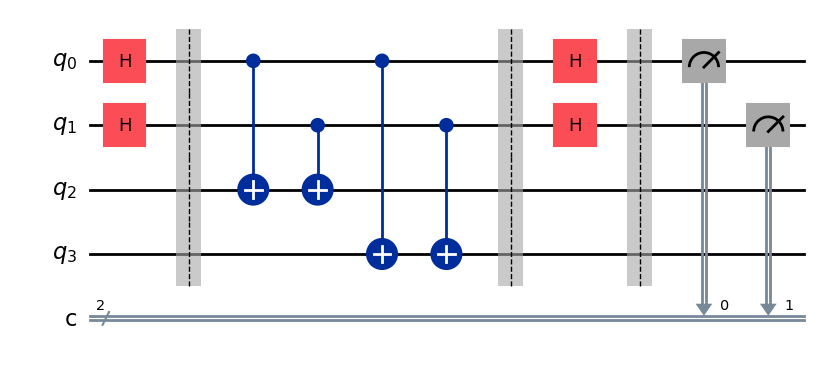

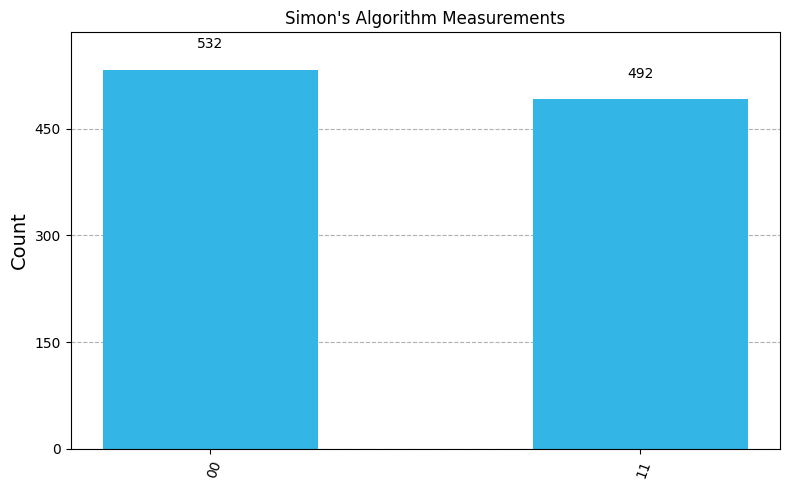

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

n = 2 # Length of our secret string
secret_s = '11'

# --- Step 1: Initialize Circuit ---
# We need 'n' input qubits, 'n' output qubits, and 'n' classical bits
qc = QuantumCircuit(n * 2, n)

# --- Step 2: Superposition ---
# Apply H-gates ONLY to the input register (qubits 0 and 1)
for i in range(n):
    qc.h(i)

qc.barrier()

# --- Step 3: THE ORACLE for s = '11' ---
# This oracle guarantees that f(x) = f(x XOR 11)
# Copy input to output
qc.cx(0, 2)
qc.cx(1, 2)
qc.cx(0, 3)
qc.cx(1, 3)

qc.barrier()

# --- Step 4: Interference ---
# Apply H-gates to the input register again
for i in range(n):
    qc.h(i)

qc.barrier()

# --- Step 5: Measurement ---
# Measure the input register (qubits 0 and 1)
for i in range(n):
    qc.measure(i, i)

# --- Visualize Circuit ---
print(f"Simon's Circuit (Hidden String s = '{secret_s}'):")
display(qc.draw('mpl'))

# --- Simulate ---
sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

# --- Visualization ---
fig = plot_histogram(
    counts, 
    title="Simon's Algorithm Measurements", 
    figsize=(8, 5), 
    color='#33b5e5' # The vibrant blue you like!
)
display(fig)


## 3. Post-Processing: Finding the Secret

When you run the code above, your histogram will show a roughly 50/50 split between two results: **`00`** and **`11`**.

Let's use classical math to solve for $s$ (which we know is $s_1 s_0$):

1. **Measurement 1:** You measured `00`.
Equation: $(0 \cdot s_1) \oplus (0 \cdot s_0) = 0$. (This tells us nothing useful).
2. **Measurement 2:** You measured `11`.
Equation: $(1 \cdot s_1) \oplus (1 \cdot s_0) = 0 \implies s_1 \oplus s_0 = 0$.
3. **Conclusion:** For $s_1 \oplus s_0 = 0$ to be true, $s_1$ must equal $s_0$. Since the string cannot be all zeros (by definition of the problem), the secret string must be **`11`**. We found it!

---

## 4. Exercises (Hands-on Practice)

### Exercise 1: One-to-One Oracle ($s = 00$)

**Goal:** Understand what happens when there is no hidden duplicate (a 1-to-1 function).

* **Task:** Rewrite the Oracle section. Erase the 4 CNOT gates and replace them with just two: `qc.cx(0, 2)` and `qc.cx(1, 3)`. This perfectly copies the input to the output.
* **Observation:** Run the circuit. Your histogram will now show equal probabilities for `00`, `01`, `10`, and `11`. This flat distribution is the quantum computer's way of telling you that the secret string $s$ is empty (`00`)!

### Exercise 2: The Math Verification

**Goal:** Prove the phase equation works.

* **Task:** If the secret string was $s = 10$, the only measurement results you would ever see are `00` and `01`.
* **Math:** Write out the equation for the measurement `01` using $z \cdot s = 0 \pmod{2}$. Does it correctly point to the secret string `10`?